# k-Nearest Neighbors (kNN) Experiments & Benchmarking

This notebook allows you to:
1. **Test a single fold** interactively with any chosen combination of the 4 kNN parameters.
2. **Run full 10-fold cross-validation experiments** across customizable parameter grids.
3. **Export benchmark results** (per-fold and summary averages) directly into CSV files for your report and statistical tests.

## 1. Imports and Environment Setup
Import dataset loaders, preprocessors, benchmarking tools, and the modular `KNNClassifier`.

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt

from parser import load_fold
from preprocessing import preprocess, preprocess_hypothyroid
from benchmarks import benchmark_classifier
from KNNClassifier import KNNClassifier

print("All modules imported successfully!")

All modules imported successfully!


---
## 2. Interactive Single Fold Test
Use this section to quickly test how a specific configuration performs on a single fold.

### Configurable Parameters:
- `dataset`: `'soybean'` (small) or `'hypothyroid'` (medium/large)
- `fold_idx`: Fold index from `0` to `9`
- `k`: Number of neighbors (e.g. `3`, `5`, `7`)
- `distance_metric`: `'euclidean'`, `'manhattan'`, `'canberra'`, or `'hamming'`
- `voting_scheme`: `'majority'` or `'inverse_distance'`
- `retention_policy`: `'never_retain'`, `'always_retain'`, `'different_class'`, or `'oblivion_by_goodness'`

In [2]:
# === Configuration for Single Fold Test ===
dataset = "soybean"             # 'soybean' or 'hypothyroid'
fold_idx = 0                    # 0 to 9
k_val = 3                       # any integer >= 1
metric = "hamming"              # 'euclidean', 'manhattan', 'canberra', 'hamming'
voting = "majority"             # 'majority', 'inverse_distance'
retention = "never_retain"      # 'never_retain', 'always_retain', 'different_class', 'oblivion_by_goodness'

# 1. Load fold data
X_train, y_train, X_test, y_test = load_fold(dataset, fold=fold_idx)

# 2. Apply preprocessing
preprocess_fn = preprocess_hypothyroid if dataset == "hypothyroid" else preprocess
X_train, X_test = preprocess_fn(X_train, X_test)

# 3. Instantiate model
model = KNNClassifier(
    k=k_val,
    distance_metric=metric,
    voting_scheme=voting,
    retention_policy=retention,
)

# 4. Benchmark performance
res = benchmark_classifier(model, X_train, y_train, X_test, y_test)

# 5. Display results
print(f"=== Single Test: {dataset.upper()} (Fold {fold_idx}) ===")
print(f"Config:          k={k_val}, metric={metric}, voting={voting}, retention={retention}")
print(f"Accuracy:        {res['accuracy'] * 100:.2f}%")
print(f"Macro F1-Score:  {res['f1_macro']:.4f}")
print(f"Training Time:   {res['training_time']:.6f} s")
print(f"Prediction Time: {res['prediction_time']:.6f} s")
print(f"Peak Memory:     {res['peak_memory_mb']:.4f} MB")

=== Single Test: SOYBEAN (Fold 0) ===
Config:          k=3, metric=hamming, voting=majority, retention=never_retain
Accuracy:        91.67%
Macro F1-Score:  0.8979
Training Time:   0.000577 s
Prediction Time: 0.007381 s
Peak Memory:     5.0290 MB


---
## 3. Automated 10-Fold Grid Search & CSV Export

The function below automatically:
1. Loops through all 10 folds for every hyperparameter combination.
2. Saves detailed per-fold metrics to `knn_experiments/{dataset}_fold_results.csv`.
3. Calculates the mean and standard deviation across all folds and saves to `knn_experiments/{dataset}_summary_results.csv`.

In [6]:
def run_knn_experiments(
    dataset_name="soybean",
    k_values=(3, 5, 7),
    distance_metrics=("euclidean", "manhattan", "canberra", "hamming"),
    voting_schemes=("majority", "inverse_distance"),
    retention_policies=("never_retain", "always_retain", "different_class", "oblivion_by_goodness"),
    n_folds=10,
    output_dir="knn_experiments",
):
    """Run all grid combinations across all folds and save CSV results."""
    os.makedirs(output_dir, exist_ok=True)
    preprocess_fn = preprocess_hypothyroid if dataset_name == "hypothyroid" else preprocess

    # Generate configuration list
    configs = []
    for k, metric, voting, retention in itertools.product(
        k_values, distance_metrics, voting_schemes, retention_policies
    ):
        name = f"KNN(k={k}, metric={metric}, voting={voting}, retention={retention})"
        configs.append((name, {
            "k": k,
            "distance_metric": metric,
            "voting_scheme": voting,
            "retention_policy": retention,
        }))

    print(f"Starting evaluation on '{dataset_name}': {len(configs)} configurations x {n_folds} folds = {len(configs) * n_folds} runs")
    
    fold_rows = []
    for fold in range(n_folds):
        print(f"-> Running Fold {fold + 1}/{n_folds}...")
        X_train, y_train, X_test, y_test = load_fold(dataset_name, fold)
        X_train, X_test = preprocess_fn(X_train, X_test)

        for name, params in configs:
            model = KNNClassifier(**params)
            res = benchmark_classifier(model, X_train, y_train, X_test, y_test)
            fold_rows.append({
                "fold": fold,
                "model": name,
                **params,
                "accuracy": res["accuracy"],
                "f1_macro": res["f1_macro"],
                "training_time": res["training_time"],
                "prediction_time": res["prediction_time"],
                "peak_memory_mb": res["peak_memory_mb"],
            })

    # 1. Detailed per-fold DataFrame
    df_folds = pd.DataFrame(fold_rows)
    fold_csv = os.path.join(output_dir, f"{dataset_name}_fold_results.csv")
    df_folds.to_csv(fold_csv, index=False)
    print(f"\n[Saved] Detailed fold results: {fold_csv}")

    # 2. Aggregated summary DataFrame across folds
    metric_cols = ["accuracy", "f1_macro", "training_time", "prediction_time", "peak_memory_mb"]
    param_cols = ["k", "distance_metric", "voting_scheme", "retention_policy"]

    summary_mean = df_folds.groupby(["model"] + param_cols, as_index=False)[metric_cols].mean()
    summary_std = df_folds.groupby(["model"] + param_cols, as_index=False)[metric_cols].std()

    for col in metric_cols:
        summary_mean[f"{col}_std"] = summary_std[col]

    summary_mean = summary_mean.sort_values(by="accuracy", ascending=False)
    summary_csv = os.path.join(output_dir, f"{dataset_name}_summary_results.csv")
    summary_mean.to_csv(summary_csv, index=False)
    print(f"[Saved] Summary results: {summary_csv}")

    return df_folds, summary_mean

---
## 4. Run Full Grid Search on Soybean Dataset
Customize the lists below if you wish to run a subset of parameters, or leave them as default to run the full assignment grid.

In [7]:
# Customize your experiment grid here:
k_list = [3, 5, 7]
metric_list = ["euclidean", "manhattan", "canberra", "hamming"]
voting_list = ["majority", "inverse_distance"]
retention_list = ["never_retain", "always_retain", "different_class", "oblivion_by_goodness"]

# Execute experiments
df_soybean_folds, df_soybean_summary = run_knn_experiments(
    dataset_name="soybean",
    k_values=k_list,
    distance_metrics=metric_list,
    voting_schemes=voting_list,
    retention_policies=retention_list,
    n_folds=10,
)

# Display Top 10 Configurations by Mean Accuracy
df_soybean_summary[["model", "accuracy", "accuracy_std", "f1_macro", "prediction_time"]].head(10)

Starting evaluation on 'soybean': 96 configurations x 10 folds = 960 runs
-> Running Fold 1/10...
-> Running Fold 2/10...
-> Running Fold 3/10...
-> Running Fold 4/10...
-> Running Fold 5/10...
-> Running Fold 6/10...
-> Running Fold 7/10...
-> Running Fold 8/10...
-> Running Fold 9/10...
-> Running Fold 10/10...

[Saved] Detailed fold results: knn_experiments\soybean_fold_results.csv
[Saved] Summary results: knn_experiments\soybean_summary_results.csv


,model,accuracy,accuracy_std,f1_macro,prediction_time
93,"KNN(k=7, metric=manhattan, voting=majority, re...",0.923394,0.030279,0.946668,0.012334
77,"KNN(k=7, metric=euclidean, voting=majority, re...",0.923394,0.030279,0.946668,0.012458
85,"KNN(k=7, metric=hamming, voting=majority, rete...",0.923394,0.030279,0.946668,0.014111
12,"KNN(k=3, metric=euclidean, voting=majority, re...",0.923190,0.026382,0.941361,0.016510
28,"KNN(k=3, metric=manhattan, voting=majority, re...",0.923190,0.026382,0.941361,0.015236
20,"KNN(k=3, metric=hamming, voting=majority, rete...",0.923190,0.026382,0.941361,0.018444
36,"KNN(k=5, metric=canberra, voting=majority, ret...",0.922819,0.020928,0.941401,0.022262
89,"KNN(k=7, metric=manhattan, voting=inverse_dist...",0.921715,0.028154,0.945581,0.023942
81,"KNN(k=7, metric=hamming, voting=inverse_distan...",0.921715,0.028154,0.945581,0.025729
24,"KNN(k=3, metric=manhattan, voting=inverse_dist...",0.921697,0.029318,0.940697,0.025108


---
## 5. Visualizing Experiment Results
Plot the top performing configurations with error bars representing standard deviation across the 10 folds.

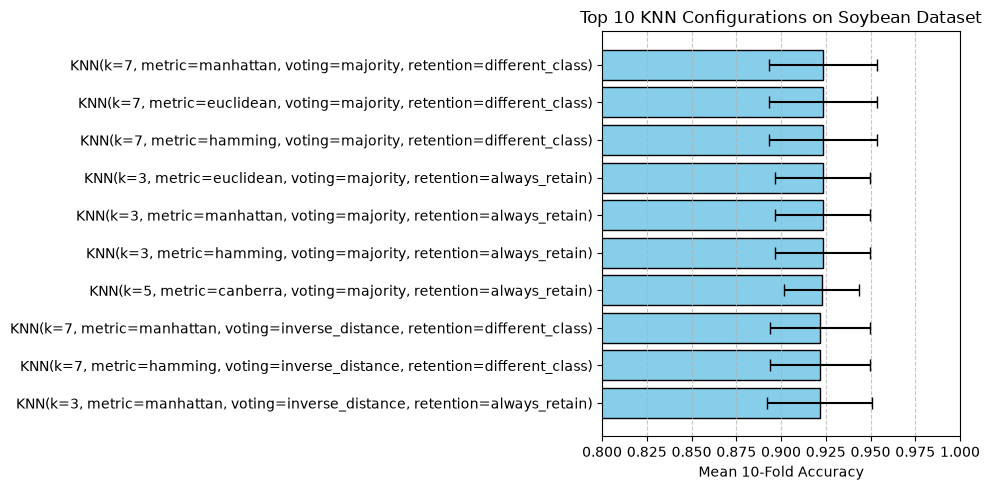

In [5]:
top_10 = df_soybean_summary.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_10["model"], top_10["accuracy"], xerr=top_10["accuracy_std"], capsize=4, color="skyblue", edgecolor="black")
plt.xlabel("Mean 10-Fold Accuracy")
plt.title("Top 10 KNN Configurations on Soybean Dataset")
plt.gca().invert_yaxis()
plt.xlim(0.8, 1.0)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()